In [1]:
# Import packages
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import pmdarima as pm
import numpy as np


In [2]:
data = pd.read_csv("../data/tsa-throughput-data-complete.csv")
data.columns = [t.partition('(')[0].strip().lower().replace(' ', '_') for t in data.columns]
print(data.head())

              datetime airport_code                         airport_name  \
0  2022-01-01 00:00:00          ANC  Ted Stevens Anchorage International   
1  2022-01-01 00:00:00          ATL     Hartsfield Atlanta International   
2  2022-01-01 00:00:00          BFL           Meadows Field, Bakersfield   
3  2022-01-01 00:00:00          BIH      Eastern Sierra Regional Airport   
4  2022-01-01 00:00:00          BQN                     Rafael Hernandez   

          city state            checkpoint  total_passenger_throughput  
0    Anchorage    AK      South Checkpoint                          62  
1      Atlanta    GA       Main Checkpoint                          17  
2  Bakersfield    CA                 BFL01                           0  
3       Bishop    CA          Checkpoint 1                           0  
4    Aguadilla    PR  Rafael Hernandez Air                         211  


In [3]:
data.head()

,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput
0,2022-01-01 00:00:00,ANC,Ted Stevens Anchorage International,Anchorage,AK,South Checkpoint,62
1,2022-01-01 00:00:00,ATL,Hartsfield Atlanta International,Atlanta,GA,Main Checkpoint,17
2,2022-01-01 00:00:00,BFL,"Meadows Field, Bakersfield",Bakersfield,CA,BFL01,0
3,2022-01-01 00:00:00,BIH,Eastern Sierra Regional Airport,Bishop,CA,Checkpoint 1,0
4,2022-01-01 00:00:00,BQN,Rafael Hernandez,Aguadilla,PR,Rafael Hernandez Air,211


In [4]:
data_proc = data.copy()
airport = 'ORD'

# Remove non-ORD and missing data values 

data_proc.drop(data_proc[data_proc['airport_code'] != airport].index, inplace=True)
data_proc.drop(data_proc[data_proc['total_passenger_throughput'] == 0].index, inplace=True)

data_proc['date'] = pd.to_datetime(data_proc['datetime']).dt.date
data_proc['month'] = pd.to_datetime(data_proc['datetime']).dt.month

#data_proc = data_proc[['datetime','total_passenger_throughput']]
#data_proc = data_proc.groupby(by=['date'],as_index=False).sum()
data_proc['datetime'] = pd.to_datetime(data_proc['datetime'])

data_weekly = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1].reset_index() 
data_weekly['week'] = pd.to_datetime(data_weekly['datetime']).dt.strftime('%U').astype(int)

data_daily = data_proc.groupby(pd.Grouper(key='datetime', freq='D'))['total_passenger_throughput'].sum().iloc[1:-1].reset_index() 
data_daily['day'] = pd.to_datetime(data_daily['datetime']).dt.strftime('%j').astype(int)

#data_proc = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1]


In [5]:
# Reserve last 25% of the data as test/evaluation data

data_proc = data_proc.iloc[:-int(len(data_proc) * 0.25)]

# Reserve last 9 months of the data as test/evaluation data
days_to_ignore = 0
days_to_forecast = 270 
data_daily_train = data_daily.iloc[days_to_ignore:-days_to_forecast]
data_weekly_train = data_weekly.iloc[:-36]

data_weekly_test = data_weekly.iloc[-36:]
data_daily_test = data_daily.iloc[-days_to_forecast:]


In [6]:
data_daily_test

,datetime,total_passenger_throughput,day
1189,2025-04-05,68346,95
1190,2025-04-06,81526,96
1191,2025-04-07,72291,97
1192,2025-04-08,62825,98
1193,2025-04-09,71141,99
...,...,...,...
1454,2025-12-26,97925,360
1455,2025-12-27,96825,361
1456,2025-12-28,99596,362
1457,2025-12-29,95498,363


In [7]:
import plotly.express as px

def plot_passenger_volumes(df: pd.DataFrame,
                           x: str,
                           y: str,
                           airport: str) -> None:
    """General function to plot the passenger data."""

    fig = px.line(df, x=x, y=y, labels={'datetime': 'Date', 'total_passenger_throughput': 'Footfall'})
    fig.update_layout(template="simple_white", font=dict(size=18), 
                      title_text='Airport Passengers: '+airport,
                      width=1000, title_x=0.5, height=500)

    return fig.show()




data_proc["total_passenger_throughput_diff"] = data_proc["total_passenger_throughput"].diff()
plot_passenger_volumes(df=data_daily, x='datetime', y='total_passenger_throughput', airport=airport)
plot_passenger_volumes(df=data_weekly, x='datetime', y='total_passenger_throughput', airport=airport)

plot_passenger_volumes(df=data_daily_train, x='datetime', y='total_passenger_throughput', airport=airport)
plot_passenger_volumes(df=data_weekly_train, x='datetime', y='total_passenger_throughput', airport=airport)

Now going forward, perform the STL decomposition

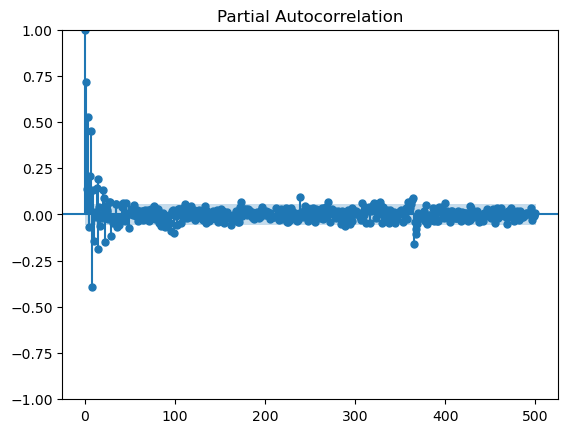

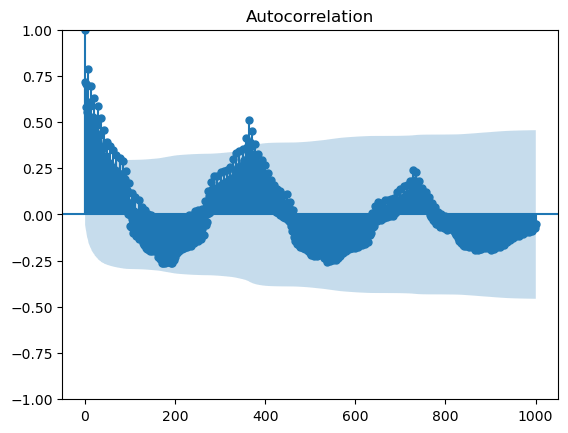

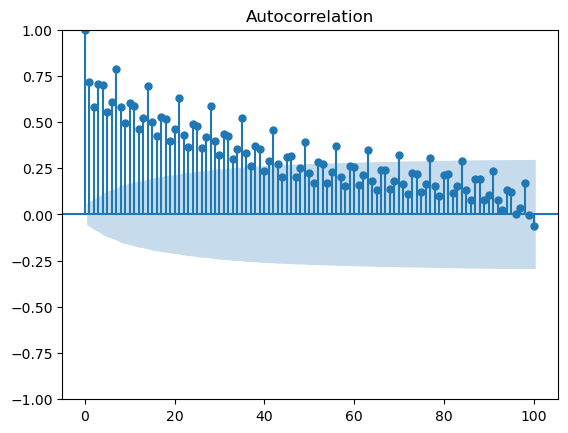

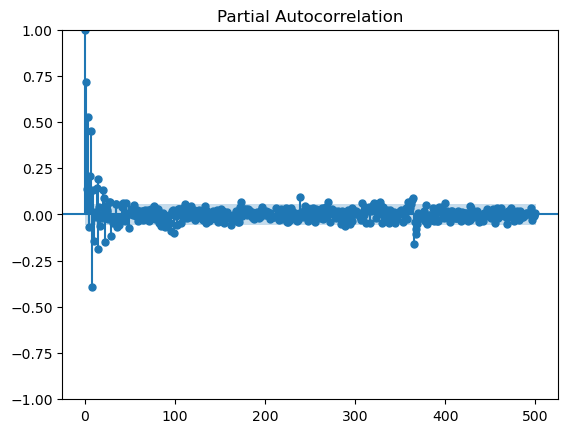

In [8]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib


plot_acf(data_daily_train['total_passenger_throughput'], lags=1000)
plot_acf(data_daily_train['total_passenger_throughput'], lags=100)
plot_pacf(data_daily_train['total_passenger_throughput'], lags=500)


 Note that above plots show significant seasonality on timescales of a year as well as a significant seasonality on timescales of a week. The ACF pattern in the second plot suggests a SARIMA model might give a good approximation. Because now we have enough weekly data points (about 156). Strangely the periodicity over monthly scales is much less significant. 

Zeroth order approach : decompose the series with an STL decomposition with period specified to be a year (i.e. = 365) and then fit a SARIMA model to the trend + residuals.

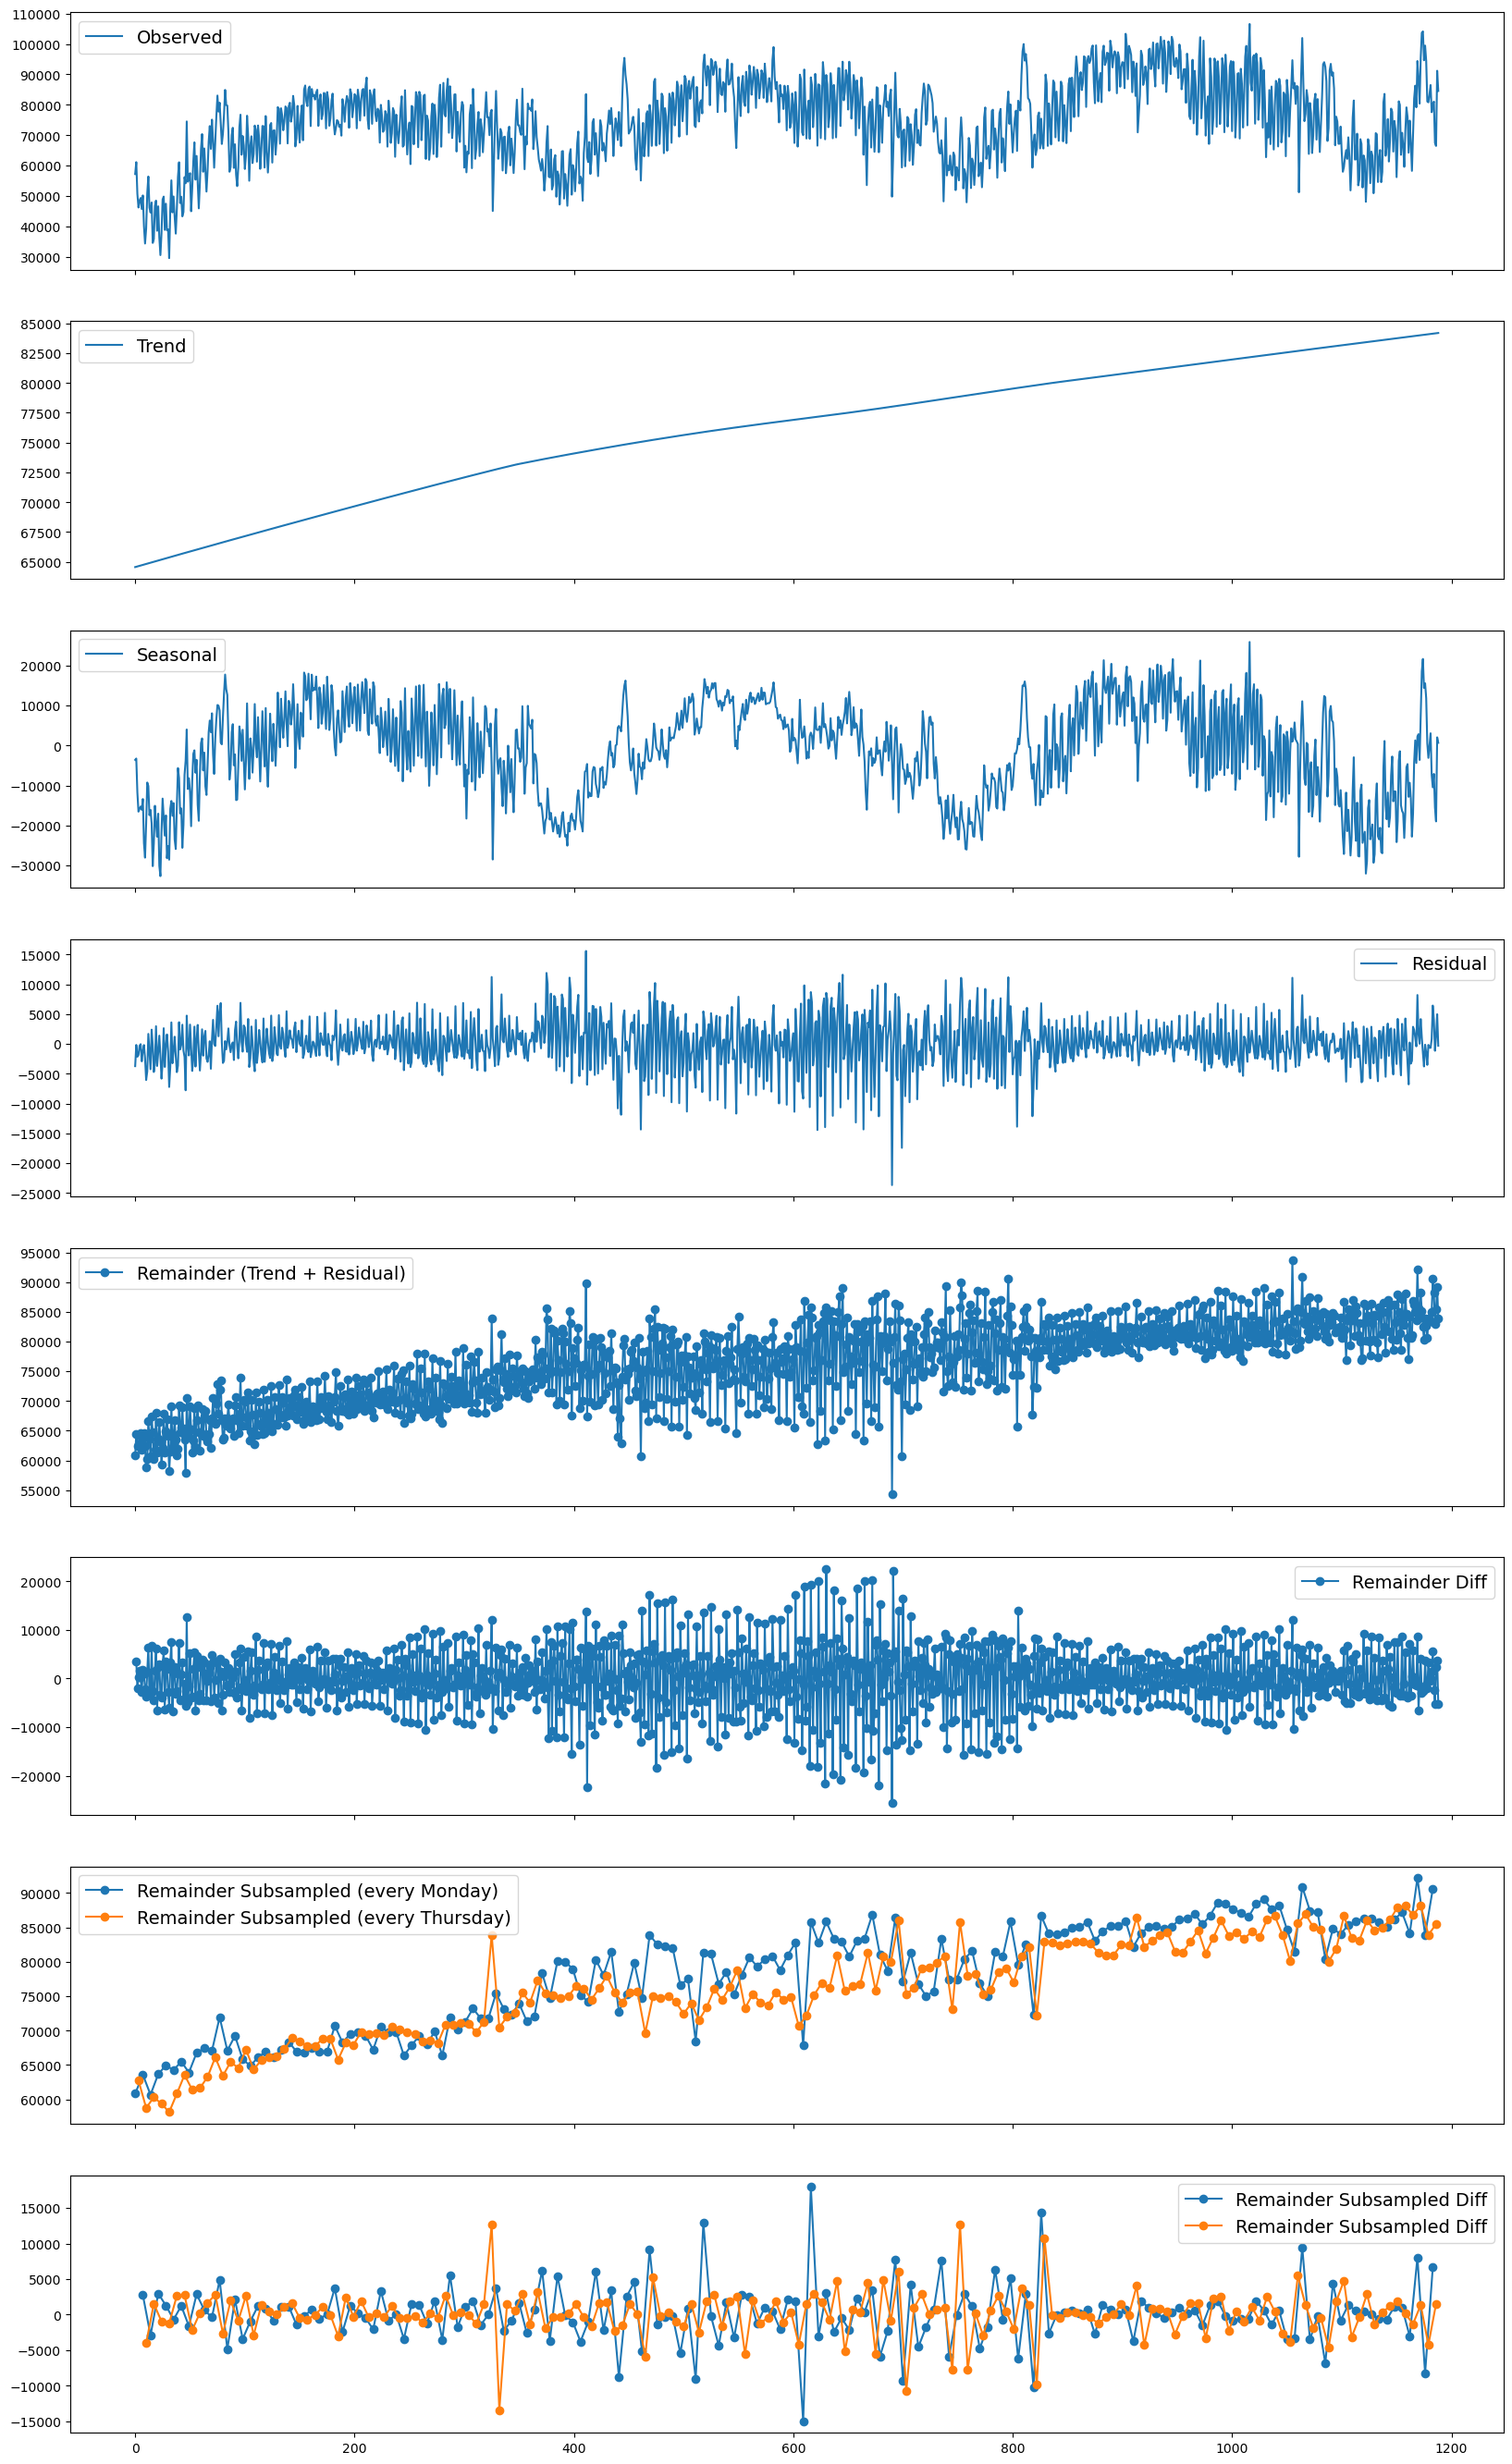

In [9]:
# Initialise the STL decomposition class with the daily data. Set robust=True to make the decomposition more resistant to outliers like leap days or bank holidays or government shutdowns :-P

stl_daily = STL(data_daily_train['total_passenger_throughput'], period=365)
stl_daily_results = stl_daily.fit()

stl_daily_trend = stl_daily_results.trend
stl_daily_seasonal = stl_daily_results.seasonal
stl_daily_resid = stl_daily_results.resid
stl_daily_base = stl_daily_results.observed 

stl_daily_trend_diff = stl_daily_trend.diff()
stl_daily_remainder = stl_daily_trend + stl_daily_resid
stl_daily_remainder_diff = stl_daily_remainder.diff()

stl_remainder_sub1 = stl_daily_remainder.iloc[::7]
stl_remainder_sub1_diff = stl_remainder_sub1.diff()

stl_remainder_sub2 = stl_daily_remainder.iloc[3::7]
stl_remainder_sub2_diff = stl_remainder_sub2.diff()



fig, ax = plt.subplots(8, 1, figsize=(20, 34), sharex=True)

ax[0].plot(stl_daily_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_daily_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_daily_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_daily_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_daily_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_daily_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
ax[6].plot(stl_remainder_sub1, label='Remainder Subsampled (every Monday)', marker='o')
ax[6].plot(stl_remainder_sub2, label='Remainder Subsampled (every Thursday)', marker='o')
ax[6].legend(fontsize=14)
ax[7].plot(stl_remainder_sub1_diff, label='Remainder Subsampled Diff', marker='o')
ax[7].plot(stl_remainder_sub2_diff, label='Remainder Subsampled Diff', marker='o')
ax[7].legend(fontsize=14)


plt.show()


From above decomposition, the remainder series (i.e Trend + Seasonal) looks strongly like difference stationary suggesting d = 1 in SARIMA fitting. 
TO learn about order of SARIMA, we PACFs of the remainder series both weekly subsamples and otherwise. 



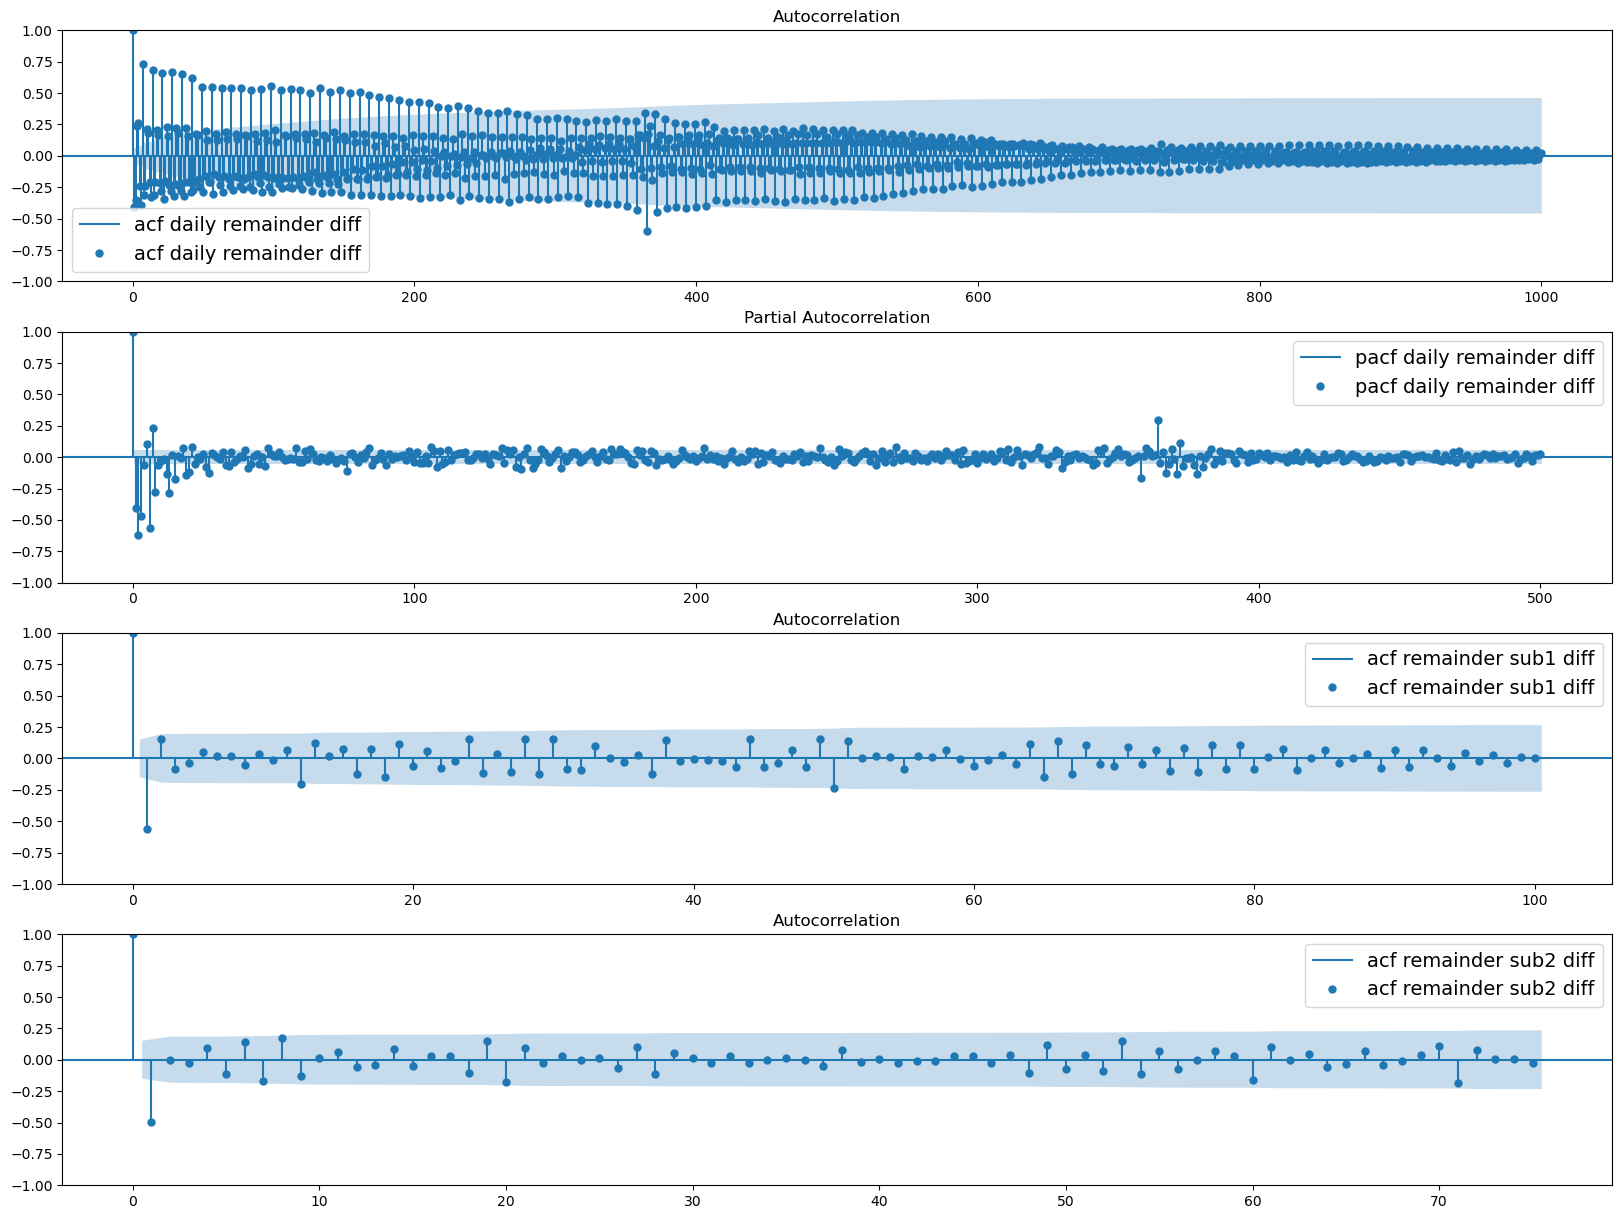

In [10]:
fig, ax = plt.subplots(4, 1, figsize=(20, 15))
plot_acf(stl_daily_remainder_diff.dropna(), lags=1000, ax=ax[0], label='acf daily remainder diff')
ax[0].legend(fontsize=14)
plot_pacf(stl_daily_remainder_diff.dropna(), lags=500, ax=ax[1], label='pacf daily remainder diff')
ax[1].legend(fontsize=14)
plot_acf(stl_remainder_sub1_diff.dropna(), lags=100, ax=ax[2], label='acf remainder sub1 diff')
ax[2].legend(fontsize=14)
plot_acf(stl_remainder_sub2_diff.dropna(), lags=75, ax=ax[3], label='acf remainder sub2 diff')
ax[3].legend(fontsize=14)




NOTE : From the ACF and PACF plots, we see that there is a clear weekly seasonality (as expected) but also a residual yearly seasonality component (small, but significant spikes in PACF at the 365 day mark). For our purposes we ignore this, because we have too few yearly-subsamples to make meaningful predictions. We also don't see a similar yearly regressive component in the pacf and acfs of the weekly subsampled remainder series. 

My guess for SARIMA orders would be ARIMA((p, 1, q), (P, 0, Q, s=7)) for the stl_daily_remainder series p,q are probably going to be pretty high (like 2 and above) (There is no additional trend across weekly deparated points that is not captured by the global trend. hence d=1 and D=0)
Let's check using auto_arima 

In [11]:
#from pmdarima import auto_arima
#auto_arima(stl_daily_remainder, seasonal=True,trace=True, m=7)

In [12]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(stl_daily_remainder, order=(2,1,1), seasonal_order=(2,0,1, 7))     # for 270 days of testing data
#model = ARIMA(stl_daily_remainder, order=(5,1,2), seasonal_order=(2,0,1, 7))     # for 180 days of testing data, which is what we are using now. The smaller test set means we can use a more complex model without overfitting to the test set.

arima_result = model.fit()  

/users/PCON0003/char1694/Miniconda/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [13]:
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                    
=======================================================================================
Dep. Variable:                               y   No. Observations:                 1189
Model:             ARIMA(2, 1, 1)x(2, 0, 1, 7)   Log Likelihood              -11270.408
Date:                         Fri, 13 Mar 2026   AIC                          22554.815
Time:                                 01:37:18   BIC                          22590.375
Sample:                                      0   HQIC                         22568.217
                                        - 1189                                         
Covariance Type:                           opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2515      0.018     14.140      0.000       0.217       0.286
ar.L2         -0.2319      0.016    -14.479      0.000      -0.263      -0.201
ma.L1         -0.9937      0.002   -536.592      0.000      -0.997      -0.990
ar.S.L7        1.1303      0.025     46.119      0.000       1.082       1.178
ar.S.L14      -0.1475      0.022     -6.721      0.000      -0.191      -0.104
ma.S.L7       -0.8485      0.022    -39.125      0.000      -0.891      -0.806
sigma2      1.112e+07   5.39e-10   2.06e+16      0.000    1.11e+07    1.11e+07
===================================================================================
Ljung-Box (L1) (Q):                  11.40   Jarque-Bera (JB):              6230.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.51   Skew:                             0.57
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.53e+32. Standard errors may be unstable.
"""

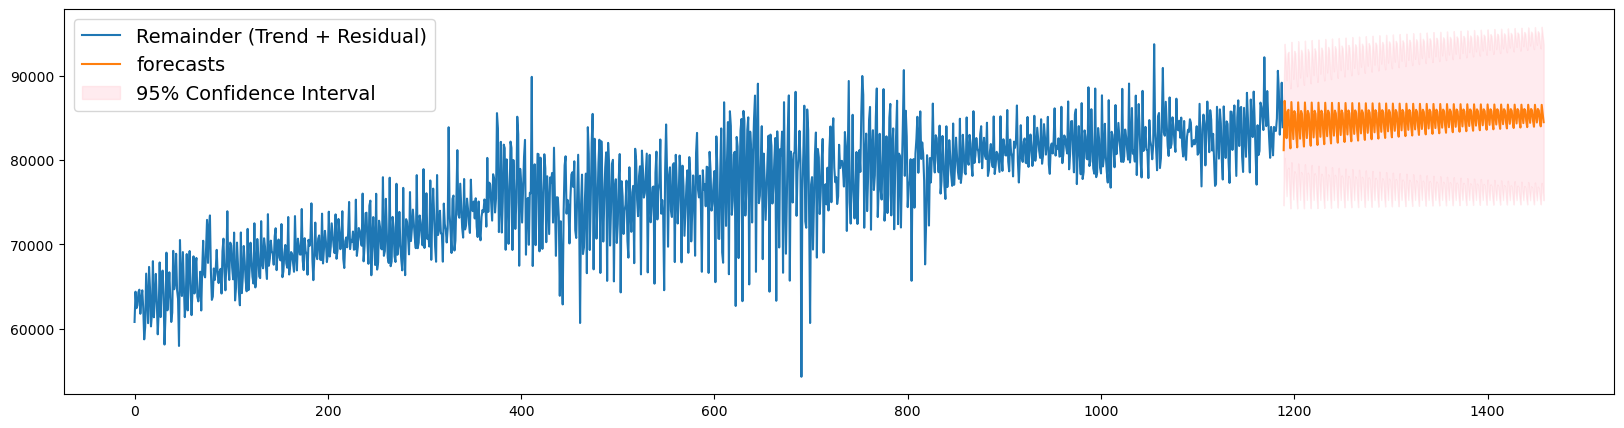

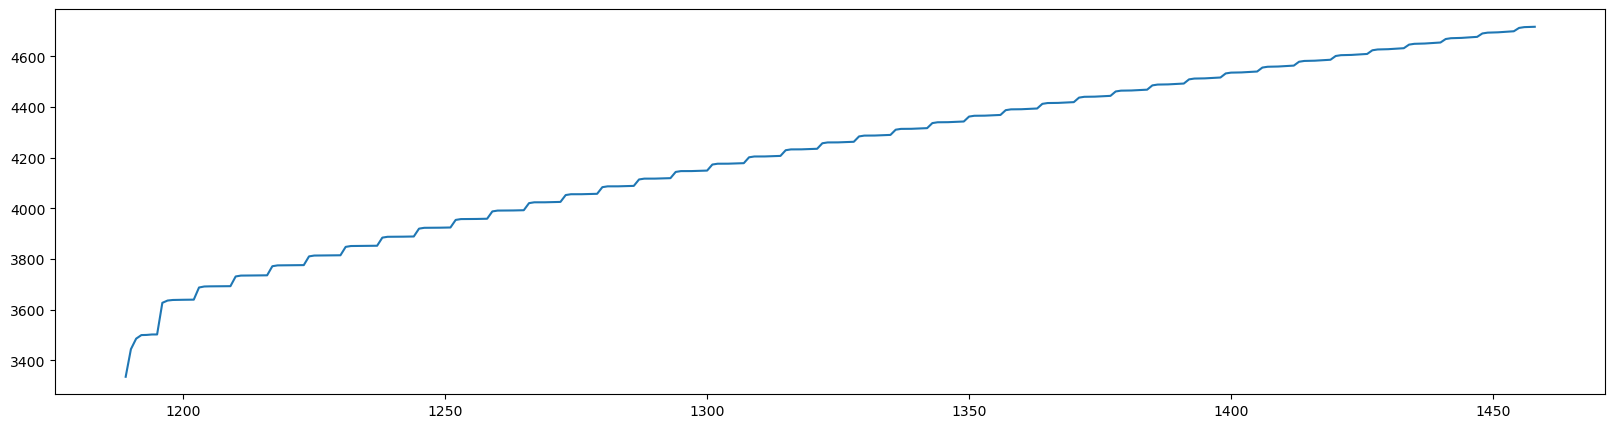

In [14]:
forecasts = arima_result.get_forecast(steps=days_to_forecast)

mean_forecasts = forecasts.predicted_mean
confidence_intervals = forecasts.conf_int()
se_mean_forecasts = forecasts.se_mean

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(stl_daily_remainder, label='Remainder (Trend + Residual)')
ax.plot(mean_forecasts, label='forecasts')
ax.fill_between(mean_forecasts.index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
ax.legend(fontsize=14)
plt.show()

fig, bx = plt.subplots(figsize=(20, 5))
bx.plot(se_mean_forecasts)
plt.show()


Naive seasonal forecast for the seasonal component of the STL decomposition. (Note that auto-correlation plots also show a residual weekly periodicity in the seasonal component of the STL decomposition)

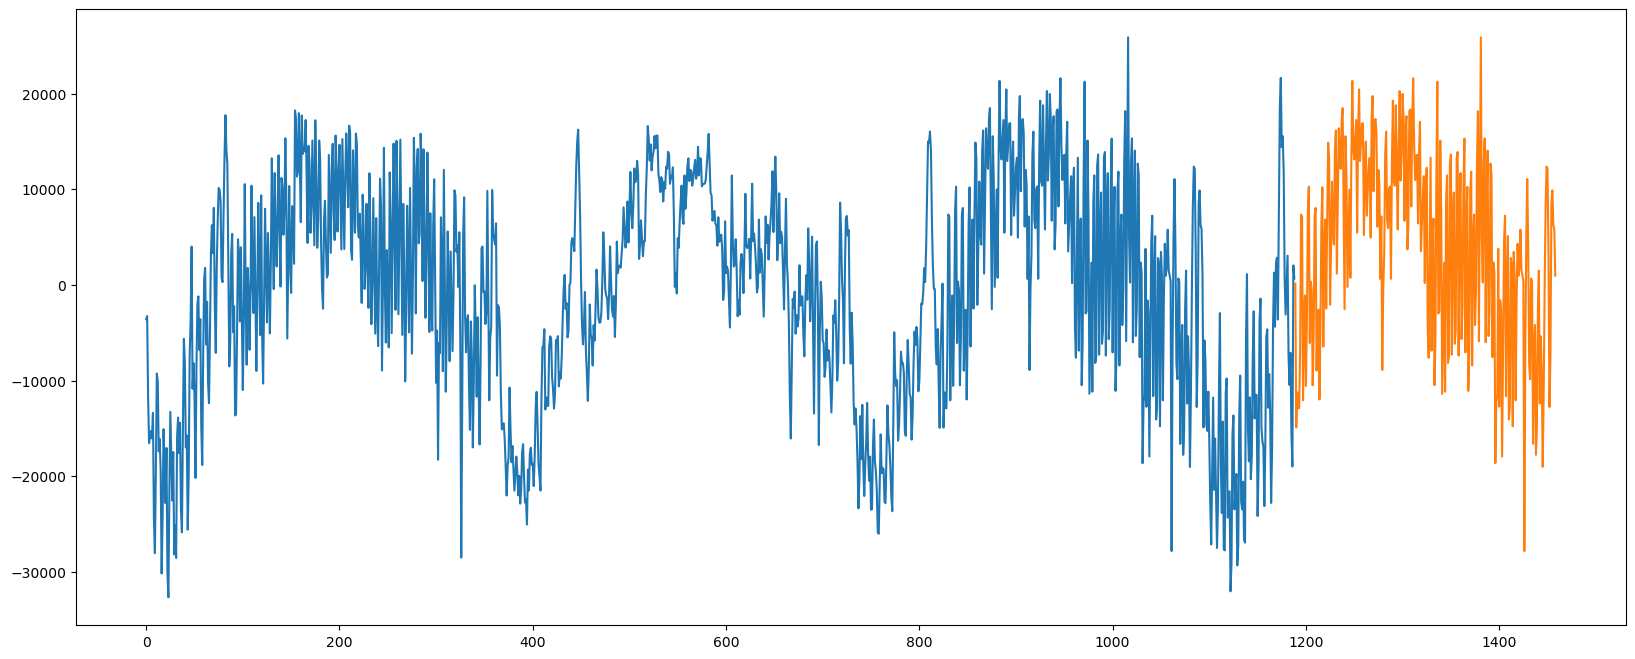

In [15]:
class NaiveSeasonalForecast:
    def __init__(self, seasonal_period: int):
        self.seasonal_period = seasonal_period

    def fit(self, series: pd.Series):
        self.last_season = series.iloc[-self.seasonal_period:]

    def predict(self, steps: int) -> pd.Series:
        repeats = (steps // self.seasonal_period) + 1
        forecast = np.tile(self.last_season, repeats)[:steps]
        return pd.Series(forecast)
    
naive_seasonal_model = NaiveSeasonalForecast(seasonal_period=365)
naive_seasonal_model.fit(stl_daily_seasonal)
stl_seasonal_forecast = naive_seasonal_model.predict(steps=days_to_forecast)

fig, ax = plt.subplots(figsize=(20,8))
ax.plot(stl_daily_seasonal)
ax.plot(mean_forecasts.index, stl_seasonal_forecast)
plt.show()

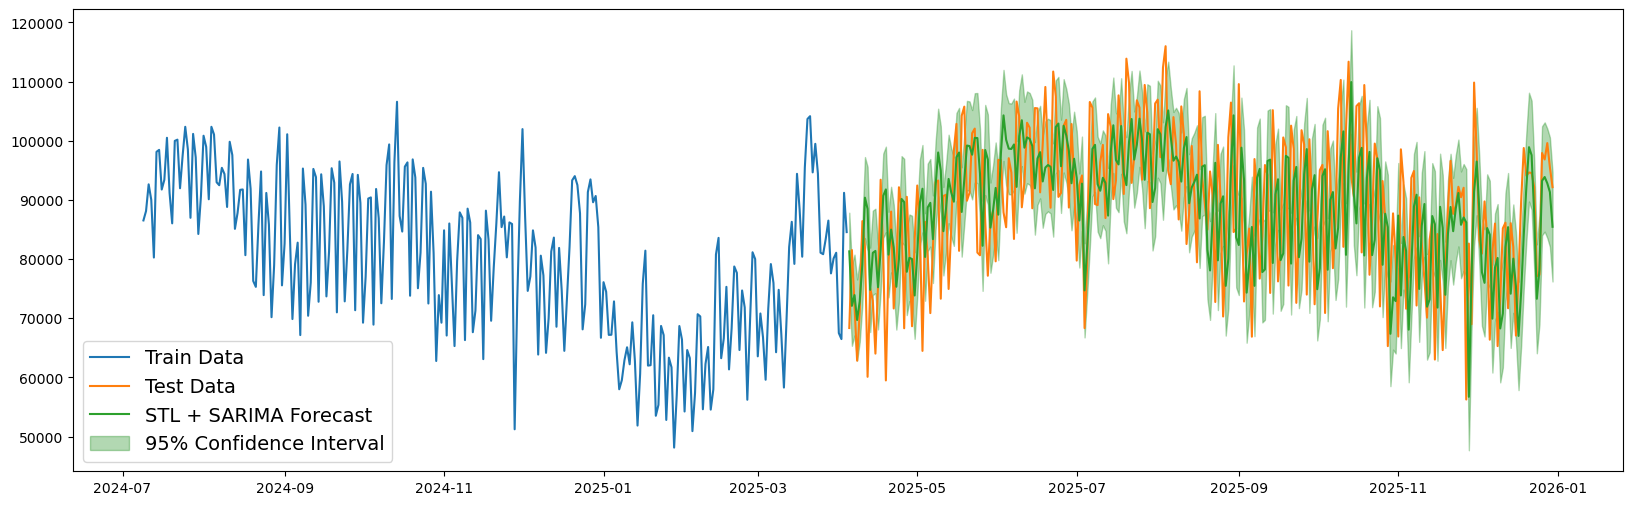

In [16]:

net_forecasts = pd.Series(mean_forecasts.values+stl_seasonal_forecast.values, index=data_daily_test['datetime'])

fig, ax = plt.subplots(figsize=(20,6))
ax.plot(data_daily_train['datetime'][-len(data_daily_test):], data_daily_train['total_passenger_throughput'][-len(data_daily_test):], label='Train Data')
ax.plot(data_daily_test['datetime'], data_daily_test['total_passenger_throughput'], label='Test Data')
ax.plot(net_forecasts.index, net_forecasts.values, label='STL + SARIMA Forecast')
ax.fill_between(net_forecasts.index, confidence_intervals.iloc[:, 0]+stl_seasonal_forecast.values, confidence_intervals.iloc[:, 1]+stl_seasonal_forecast.values, color='green', alpha=0.3, label='95% Confidence Interval')
ax.legend(fontsize=14)  
plt.show()

In [17]:
class NaiveSeasonalWithDrift:
    def __init__(self, season_length):
        self.season_length = season_length
        self.deltas = None
        self.last_value = None
    def fit(self, ts):
        if isinstance(ts, pd.Series):
            ts = ts.values
        s = self.season_length
        if len(ts) < s + 1:
            raise ValueError("Need more data than one season")
        self.deltas = ts[-s:] - ts[-s-1:-1]
        self.last_value = ts[-1]

    def forecast(self, h):
        s = self.season_length
        forecasts = np.zeros(h)
        forecasts[0] = self.last_value + self.deltas[0]
        for i in range(1, h):
            forecasts[i] = forecasts[i-1]+self.deltas[i%s]
        return forecasts

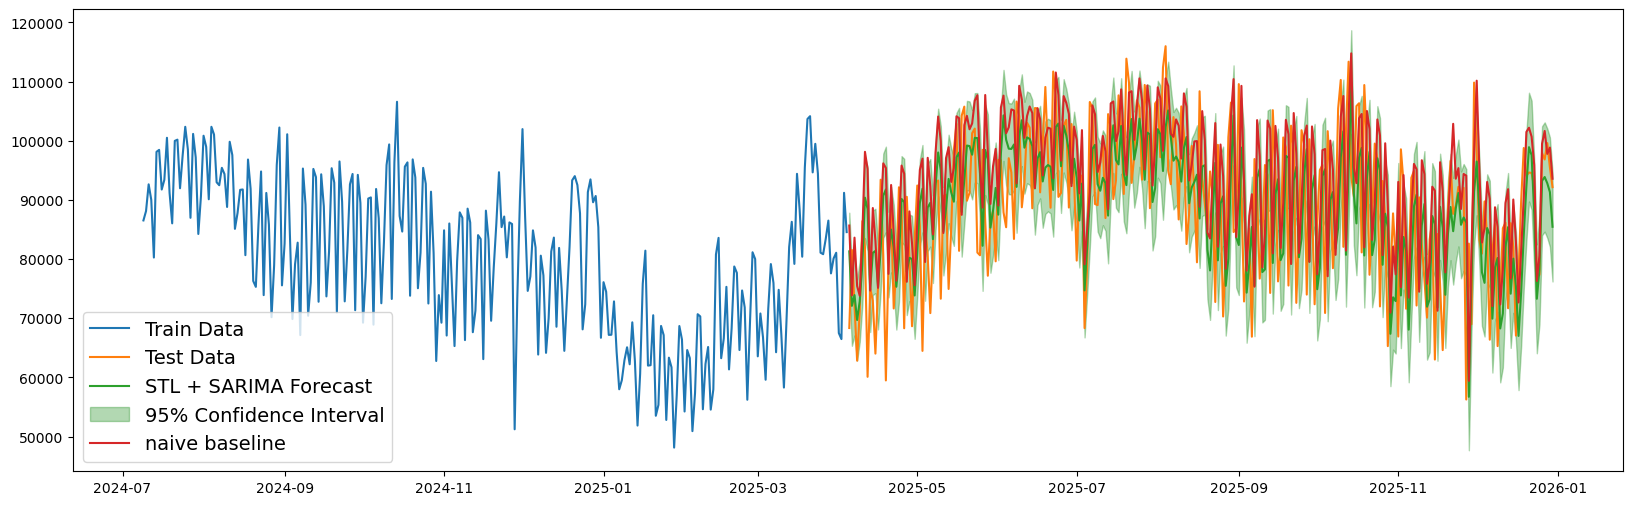

In [18]:
class NaiveSeasonalWithDriftForecast(NaiveSeasonalWithDrift):
    def predict(self, steps):   
        return pd.Series(self.forecast(steps))
nswd = NaiveSeasonalWithDriftForecast(season_length=365)
nswd.fit(data_daily_train['total_passenger_throughput'])
nswd_forecast = nswd.predict(steps=days_to_forecast)

fig, ax = plt.subplots(figsize=(20,6))
ax.plot(data_daily_train['datetime'][-len(data_daily_test):], data_daily_train['total_passenger_throughput'][-len(data_daily_test):], label='Train Data')
ax.plot(data_daily_test['datetime'], data_daily_test['total_passenger_throughput'], label='Test Data')
ax.plot(net_forecasts.index, net_forecasts.values, label='STL + SARIMA Forecast')
ax.fill_between(net_forecasts.index, confidence_intervals.iloc[:, 0]+stl_seasonal_forecast.values, confidence_intervals.iloc[:, 1]+stl_seasonal_forecast.values, color='green', alpha=0.3, label='95% Confidence Interval')
ax.plot(net_forecasts.index, nswd_forecast, label='naive baseline')
ax.legend(fontsize=14)  
plt.show()

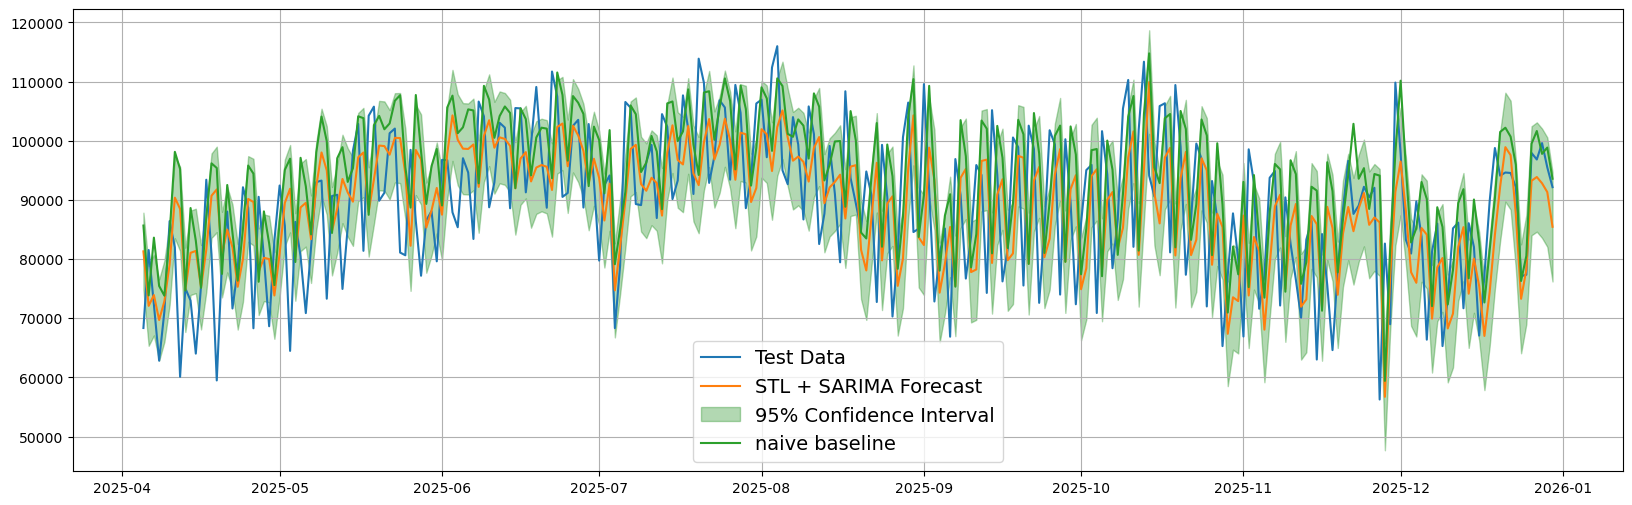

In [19]:
fig, ax = plt.subplots(figsize=(20,6))
#ax.plot(data_daily_train['datetime'][-len(data_daily_test):], data_daily_train['total_passenger_throughput'][-len(data_daily_test):], label='Train Data')
ax.plot(data_daily_test['datetime'], data_daily_test['total_passenger_throughput'], label='Test Data')
ax.plot(net_forecasts.index, net_forecasts.values, label='STL + SARIMA Forecast')
ax.fill_between(net_forecasts.index, confidence_intervals.iloc[:, 0]+stl_seasonal_forecast.values, confidence_intervals.iloc[:, 1]+stl_seasonal_forecast.values, color='green', alpha=0.3, label='95% Confidence Interval')
ax.plot(net_forecasts.index, nswd_forecast, label='naive baseline')
ax.legend(fontsize=14)  
plt.grid()
plt.show()

In [20]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_squared_error

mse = mean_squared_error(data_daily_test['total_passenger_throughput'], net_forecasts)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(data_daily_test['total_passenger_throughput'], net_forecasts)

mse_baseline = mean_squared_error(data_daily_test['total_passenger_throughput'], nswd_forecast)
rmse_baseline = root_mean_squared_error(data_daily_test['total_passenger_throughput'], nswd_forecast)
mape_baseline = mean_absolute_percentage_error(data_daily_test['total_passenger_throughput'], nswd_forecast)

In [21]:
print(rmse,rmse_baseline, rmse/rmse_baseline)
print(mape, mape_baseline, mape/mape_baseline)
print(mse, mse_baseline, mse/mse_baseline)

12633.975317901906 14001.186791628561 0.9023503154358227
0.11998995782437355 0.13570551626004884 0.8841936653071641
159617332.3333546 196033231.57407406 0.8142360917671289
